<a href="https://colab.research.google.com/github/nikasvesko/repic/blob/main/regresija.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
np.random.seed(42)

blood_pressure = 2 * np.random.rand(100, 1)

inflammation_level = 4 + 3 * blood_pressure + np.random.randn(100, 1)




data = pd.DataFrame({

'Blood Pressure (mmHg)': blood_pressure.flatten(),

'Inflammation Level (Biomarker)': inflammation_level.flatten()

})

print(data.head())


   Blood Pressure (mmHg)  Inflammation Level (Biomarker)
0               0.749080                        6.334288
1               1.901429                        9.405278
2               1.463988                        8.483724
3               1.197317                        5.604382
4               0.312037                        4.716440


In [7]:
data.describe()

,Blood Pressure (mmHg),Inflammation Level (Biomarker)
count,100.000000,100.000000
mean,0.940361,6.820004
std,0.594979,1.879138
min,0.011044,3.238062
25%,0.386402,5.302794
50%,0.928285,6.676056
75%,1.460406,8.297638
max,1.973774,11.044395


In [9]:
tab = data.describe().T
tab

,count,mean,std,min,25%,50%,75%,max
Blood Pressure (mmHg),100.0,0.940361,0.594979,0.011044,0.386402,0.928285,1.460406,1.973774
Inflammation Level (Biomarker),100.0,6.820004,1.879138,3.238062,5.302794,6.676056,8.297638,11.044395


In [13]:
data.columns



Index(['Blood Pressure (mmHg)', 'Inflammation Level (Biomarker)'], dtype='object')

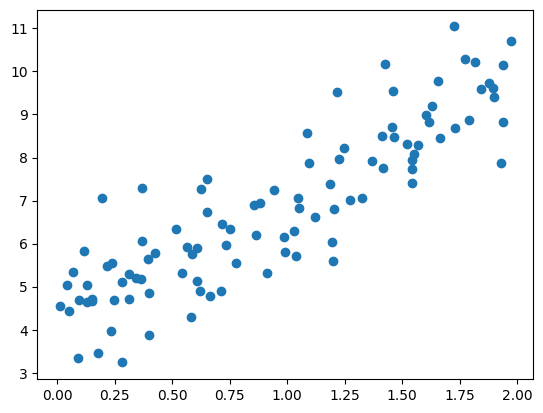

In [18]:
plt.scatter(data.iloc[:,0],data.iloc[:,1])  #dva argumenta

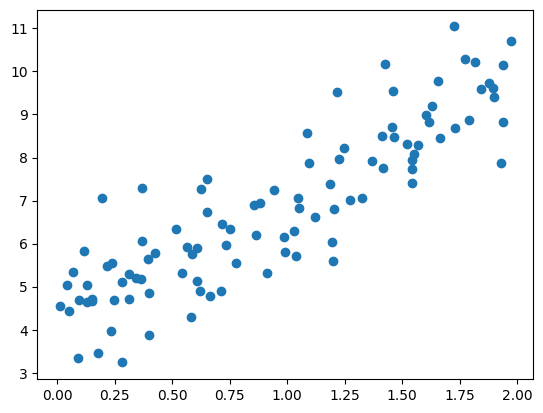

In [14]:
plt.scatter(data['Blood Pressure (mmHg)'], data['Inflammation Level (Biomarker)'])

In [12]:
tab[['std', 'mean']] #indeksiranje, bitno da je dupla uglata jer je ovo unutra lista

,std,mean
Blood Pressure (mmHg),0.594979,0.940361
Inflammation Level (Biomarker),1.879138,6.820004


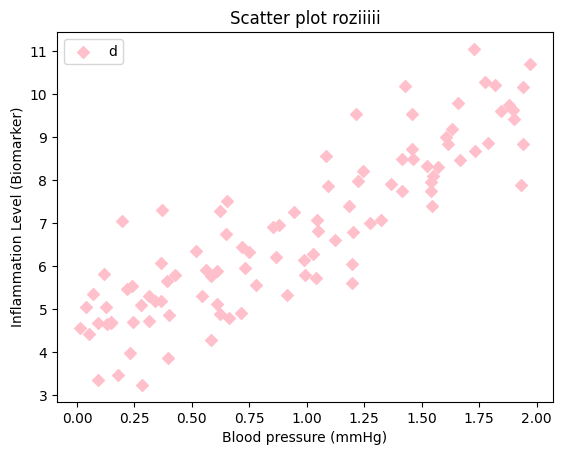

In [33]:
graf= plt.scatter(blood_pressure, inflammation_level,color='pink', marker= 'D', label='Patient Data')
plt.xlabel('Blood pressure (mmHg)')
plt.ylabel('Inflammation Level (Biomarker)')
plt.title('Scatter plot roziiiii')
plt.legend('dijamanti')
plt.show()

In [19]:
data.iloc[:,0]

,Blood Pressure (mmHg)
0,0.749080
1,1.901429
2,1.463988
3,1.197317
4,0.312037
...,...
95,0.987591
96,1.045466
97,0.855082
98,0.050838


In [34]:
bp_train, bp_test, infl_train, infl_test = train_test_split(blood_pressure, inflammation_level, test_size=0.2, random_state=42)


In [35]:
model = LinearRegression()
model.fit(bp_train, infl_train) #fitamo na vec postojece vrijednosti

LinearRegression()

In [36]:
model

LinearRegression()

In [37]:
model.intercept_ #isjecak

array([4.14291332])

In [38]:
model.coef_  #nagib, za promjenu u X imam 2,79 promjena u Y

array([[2.79932366]])

In [42]:
infl_pred = model.predict(bp_test)
infl_pred

array([[4.49875411],
       [9.15273606],
       [8.46643942],
       [7.85214193],
       [5.59173117],
       [6.6071719 ],
       [5.77852817],
       [8.975125  ],
       [4.25815864],
       [6.23983135],
       [6.56122114],
       [7.54434267],
       [8.70839426],
       [9.45538878],
       [4.81247932],
       [5.01640666],
       [8.46098398],
       [4.55746321],
       [8.80346608],
       [5.09761775]])

In [55]:
infl_pred_series = pd.Series(np.squeeze(infl_pred))  #jer moramo smanjiti dimenziju
infl_pred_series


,0
0,4.498754
1,9.152736
2,8.466439
3,7.852142
4,5.591731
5,6.607172
6,5.778528
7,8.975125
8,4.258159
9,6.239831


Text(0, 0.5, 'prediktivni')

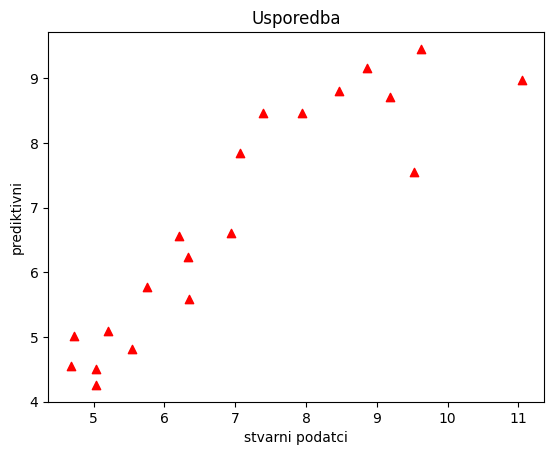

In [62]:
plt.scatter(infl_test, infl_pred, color = 'red', marker = '^' ,label = 'usporedba')
plt.title('Usporedba')
plt.xlabel('stvarni podatci')
plt.ylabel('prediktivni')

In [ ]:
#ono sto smo mi modelom izracunali upalu iz tlaka

In [66]:
df1 = pd.DataFrame({
    "infl_pred": infl_pred.squeeze(),
    "infl_test": infl_test.squeeze()
})
df1   #indeksirana matrica je dataframe

,infl_pred,infl_test
0,4.498754,5.037904
1,9.152736,8.865488
2,8.466439,7.396518
3,7.852142,7.065746
4,5.591731,6.343712
5,6.607172,6.942462
6,5.778528,5.757981
7,8.975125,11.044395
8,4.258159,5.038909
9,6.239831,6.334288


In [70]:
abs(df1['infl_test']- df1['infl_pred']).sum() #ukupna greška

np.float64(11.826851558379554)

In [73]:
mse= mean_squared_error(infl_test, infl_pred)
mse

0.6536995137170021

In [74]:
df1['infl_test'].std()

1.889211064098559